In [39]:
from bloqade.analog import load, save
from bloqade.analog.atom_arrangement import Square
import numpy as np
import os
import matplotlib.pyplot as plt
from bloqade.analog import get_capabilities


from bokeh.io import output_notebook
output_notebook() 

if not os.path.isdir("data"):
    os.mkdir("data")

# setting the seed
rng = np.random.default_rng(1234)
# a=5
# lattice =Square(4, lattice_spacing=a).apply_defect_density(0.3, rng=rng).remove_vacant_sites()

from bloqade.analog import start



def run_rydberg(points):
    geometry = start.add_position(points)

    #durations = [0.3, 1.6, 0.3]

    # lattice.show()
    # geometry.show()

    # get capabilities for Aquila
    aquila_capabilities = get_capabilities()

    C6=float(aquila_capabilities.capabilities.rydberg.c6_coefficient)
    Omega_max= float(aquila_capabilities.capabilities.rydberg.global_.rabi_frequency_max) #2*np.pi*4 #

    Rba=np.power(2,3/4)
    Rb=Rba*a
    print(Rb)
    # Rb=12

    Delta_end= (C6)/Rb**6 #final detuning 2*np.pi*11

    RbO=(C6/Omega_max)**(1/6)
    RbD=(C6/Delta_end)**(1/6)

    from bloqade.analog import piecewise_linear

    T_max=4
    sweep_time = 0.8*T_max #time length of the protocol 
    ramp_time=0.1*T_max

    rabi_amplitude_values = [0.0, Omega_max, Omega_max, 0.0]
    detuning_values = [-Delta_end, -Delta_end, Delta_end, Delta_end]
    durations = [ramp_time, sweep_time, ramp_time]

    RabiProtocol = piecewise_linear(durations,rabi_amplitude_values)
    DeltaProtocol = piecewise_linear(durations,detuning_values)

    # RabiProtocol.show()
    # DeltaProtocol.show()

    mis_udg_program=(
            # lattice.rydberg.rabi.amplitude.uniform.apply(RabiProtocol)
            # .detuning.uniform.apply(DeltaProtocol)
            geometry.rydberg.rabi.amplitude.uniform.apply(RabiProtocol).detuning.uniform.apply(DeltaProtocol)
    )

    result = mis_udg_program.bloqade.python().run(100,interaction_picture=True)

    report = result.report()
    # report.show()

    data = result.report().bitstrings()

    temp = [0]*len(points)
    for i in range(len(data[0])):
        temp += data[0][i]

    # make values greater than 50 into 1, and less than 50 into 0
    # temp = [1 if x > 8200 else 0 for x in temp]
    temp = [float(x/10000) for x in temp]
    temp

    bitstrings, counts = np.unique(data[0], axis=0, return_counts=True)


    #get index of the maximum value in counts
    max = bitstrings[np.argmax(counts)]
    inv = [1 if x == 0 else 0 for x in max]
    # make a dictionary mapping the values in env to their sam indexed coordinates in points
    mapping = {i: points[i] for i in range(len(points))}
    mapping

    # inv 
    print(points)
    print(inv)

    max_set = [cordinate for i, cordinate in enumerate(points) if inv[i] == 1]
    remaining_set = [cordinate for i, cordinate in enumerate(points) if inv[i] == 0]

    if not max_set:
        max_set = remaining_set
        remaining_set = []

    return remaining_set, max_set


Loading BokehJS ...

In [35]:
np.power(2,3/4)

np.float64(1.681792830507429)

# Main

In [ ]:
a = 5
# a = 1 # a;ready scaled here

# mul;tiply all the points x5 
og_points = [(8,  5),  (7,  4),  (5,  4), (8,  3),  (4,  3),  (7,  3), (5,  2), (3,  2),  (7,  2),  (2,  2), (6,  3), (4,  1), (1,  1), (3,  1), (2,  0), (0,  0)]
og_points = [(x*a,y*a) for x,y in og_points] #TODO add back

points = og_points.copy()
coloring = []

while points:
    remaining_set, max_set = run_rydberg(points)
    points = remaining_set
    coloring.append(max_set)

# plot then colored graph
# fig, ax = plt.subplots()
print(coloring)
visualize_colored_groups(coloring)

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 5), (0, 10), (5, 5), (10, 10), (10, 15), (10, 0), (0, 15), (15, 5), (10, 10)]
[0, 0, 1, 0, 1, 0, 1, 1, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 5), (0, 10), (10, 10), (10, 0), (10, 10)]
[0, 1, 1, 1, 0]
8.408964152537145
[(10, 5), (10, 10)]
[1, 0]
8.408964152537145
[(10, 10)]
[1]
[[(5, 5), (10, 15), (0, 15), (15, 5)], [(0, 10), (10, 10), (10, 0)], [(10, 5)], [(10, 10)]]


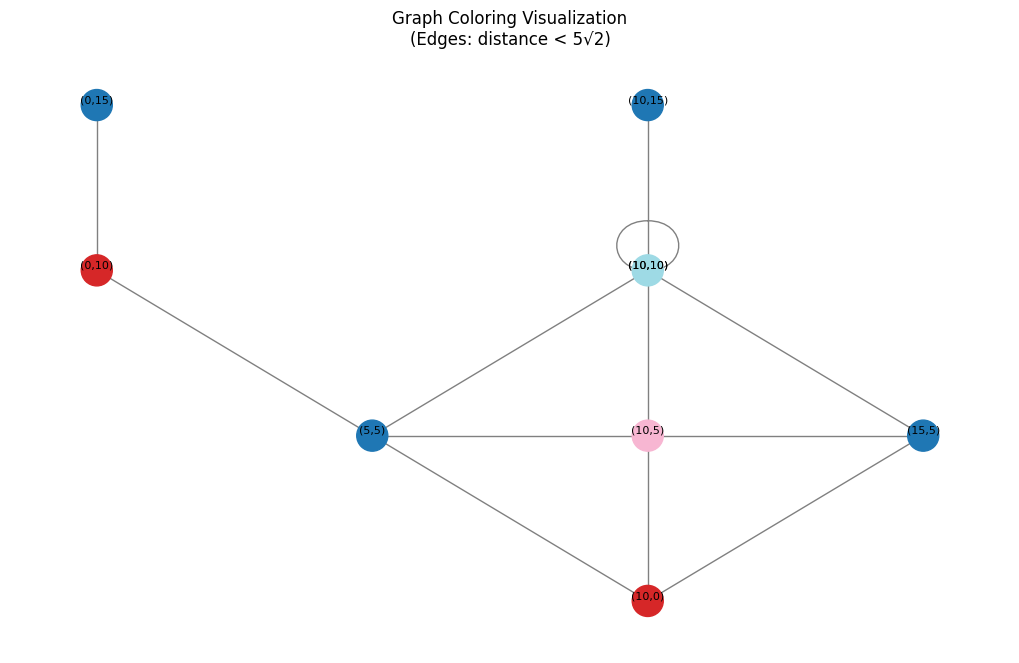

8.408964152537145
[(0, 0), (0, 0), (10, 15), (10, 0), (0, 10), (10, 15), (15, 5), (5, 5), (0, 10)]
[1, 0, 0, 0, 0, 1, 1, 0, 1]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(0, 0), (10, 15), (10, 0), (0, 10), (5, 5)]
[1, 1, 1, 1, 0]
8.408964152537145
[(5, 5)]
[1]
[[(0, 0), (10, 15), (15, 5), (0, 10)], [(0, 0), (10, 15), (10, 0), (0, 10)], [(5, 5)]]


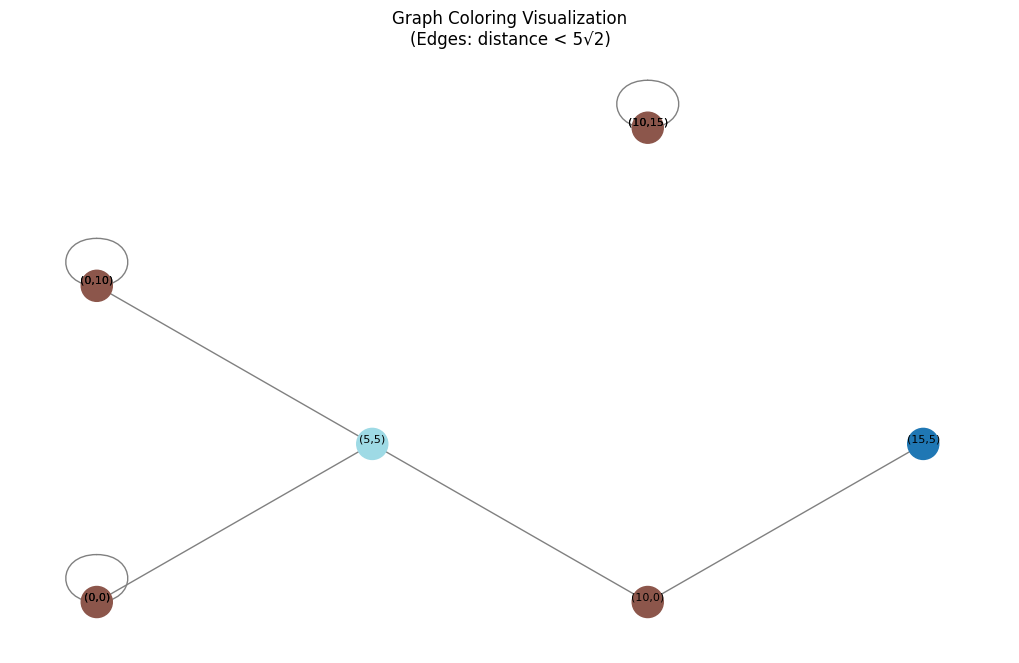

8.408964152537145
[(5, 15), (15, 15), (10, 5), (0, 10), (10, 15), (15, 5), (15, 10), (10, 10), (10, 0)]
[0, 1, 0, 1, 0, 0, 0, 0, 1]
8.408964152537145
[(5, 15), (10, 5), (10, 15), (15, 5), (15, 10), (10, 10)]
[1, 1, 0, 0, 0, 0]
8.408964152537145
[(10, 15), (15, 5), (15, 10), (10, 10)]
[1, 1, 0, 0]
8.408964152537145
[(15, 10), (10, 10)]
[1, 0]
8.408964152537145
[(10, 10)]
[1]
[[(15, 15), (0, 10), (10, 0)], [(5, 15), (10, 5)], [(10, 15), (15, 5)], [(15, 10)], [(10, 10)]]


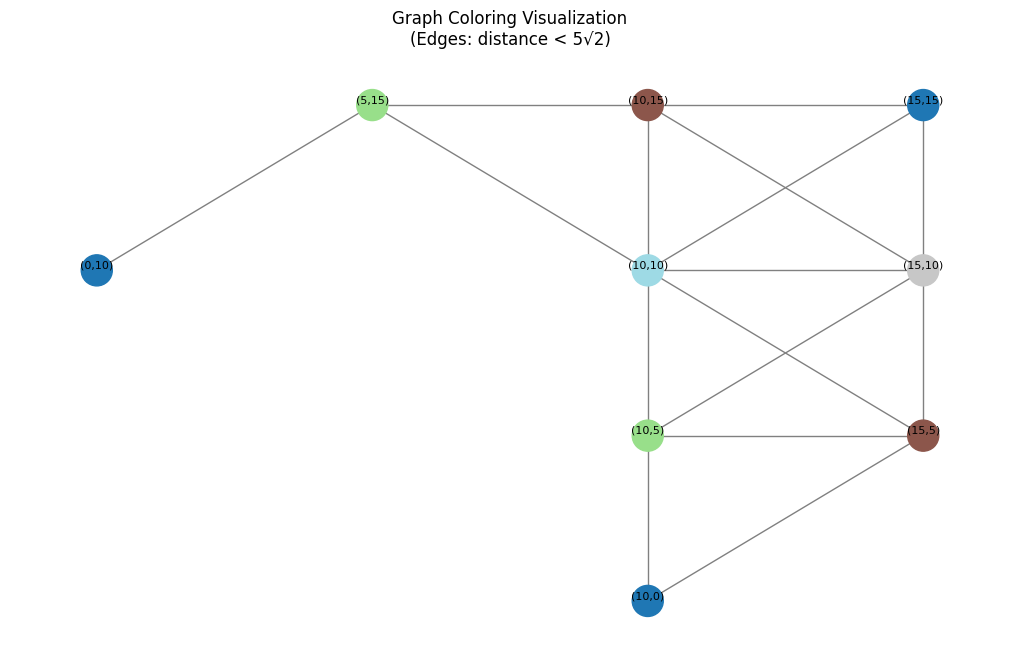

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 0), (0, 15), (0, 10), (15, 5), (15, 0), (15, 5), (10, 0), (15, 0), (15, 5)]
[0, 0, 1, 0, 0, 0, 0, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 0), (0, 15), (15, 5), (15, 0), (15, 5), (10, 0), (15, 0), (15, 5)]
[0, 1, 0, 0, 0, 1, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 0), (15, 5), (15, 0), (15, 5), (15, 0), (15, 5)]
[1, 0, 0, 0, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(15, 5), (15, 0), (15, 5), (15, 0), (15, 5)]
[0, 0, 1, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(15, 5), (15, 0), (15, 0), (15, 5)]
[0, 0, 0, 1]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(15, 5), (15, 0), (15, 0)]
[0, 0, 1]
8.408964152537145
[(15, 5), (15, 0)]
[1, 0]
8.408964152537145
[(15, 0)]
[1]
[[(0, 10)], [(0, 15), (10, 0)], [(10, 0)], [(15, 5)], [(15, 5)], [(15, 0)], [(15, 5)], [(15, 0)]]


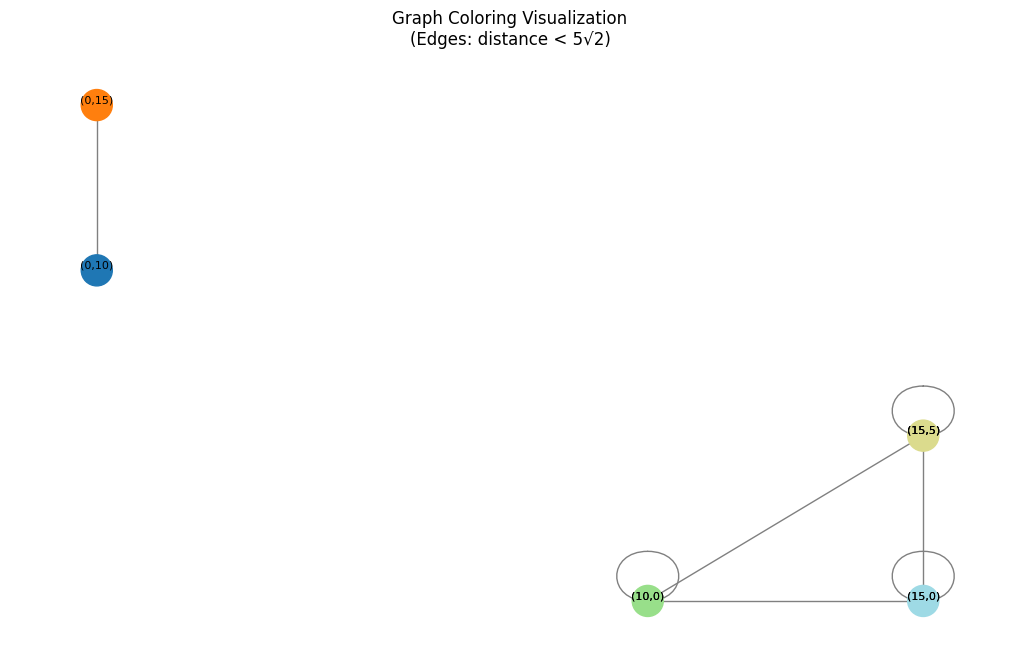

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 10), (15, 10), (5, 0), (10, 5), (5, 0), (15, 10), (15, 5), (10, 15), (10, 15)]
[0, 0, 1, 0, 0, 0, 1, 0, 1]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 10), (15, 10), (10, 5), (5, 0), (15, 10), (10, 15)]
[0, 0, 0, 1, 0, 1]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 10), (15, 10), (10, 5), (15, 10)]
[0, 0, 1, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 10), (15, 10), (15, 10)]
[0, 1, 0]
8.408964152537145
[(10, 10), (15, 10)]
[0, 1]
8.408964152537145
[(10, 10)]
[1]
[[(5, 0), (15, 5), (10, 15)], [(5, 0), (10, 15)], [(10, 5)], [(15, 10)], [(15, 10)], [(10, 10)]]


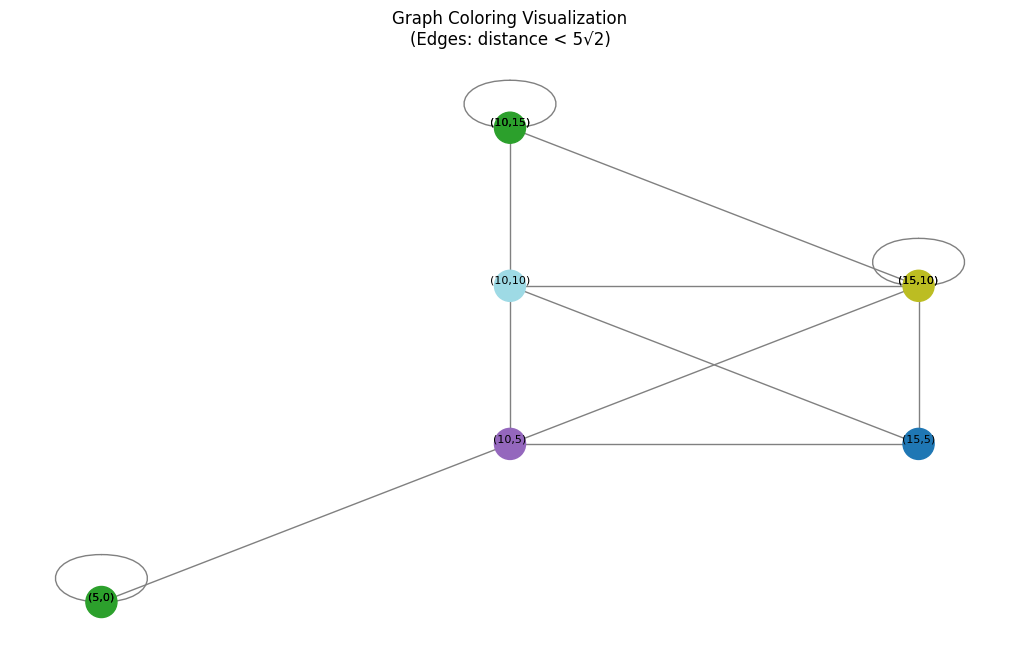

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 10), (0, 10), (15, 5), (15, 5), (15, 15), (15, 0), (15, 5), (15, 5), (10, 0)]
[0, 1, 0, 0, 1, 0, 0, 0, 1]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 10), (15, 5), (15, 5), (15, 0), (15, 5), (15, 5)]
[1, 0, 0, 1, 0, 0]
8.408964152537145
[(15, 5), (15, 5), (15, 5), (15, 5)]
[0, 1, 0, 0]
8.408964152537145
[(15, 5), (15, 5), (15, 5)]
[1, 0, 0]
8.408964152537145
[(15, 5), (15, 5)]
[1, 0]
8.408964152537145
[(15, 5)]
[1]
[[(0, 10), (15, 15), (10, 0)], [(10, 10), (15, 0)], [(15, 5)], [(15, 5)], [(15, 5)], [(15, 5)]]


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)
/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)
/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


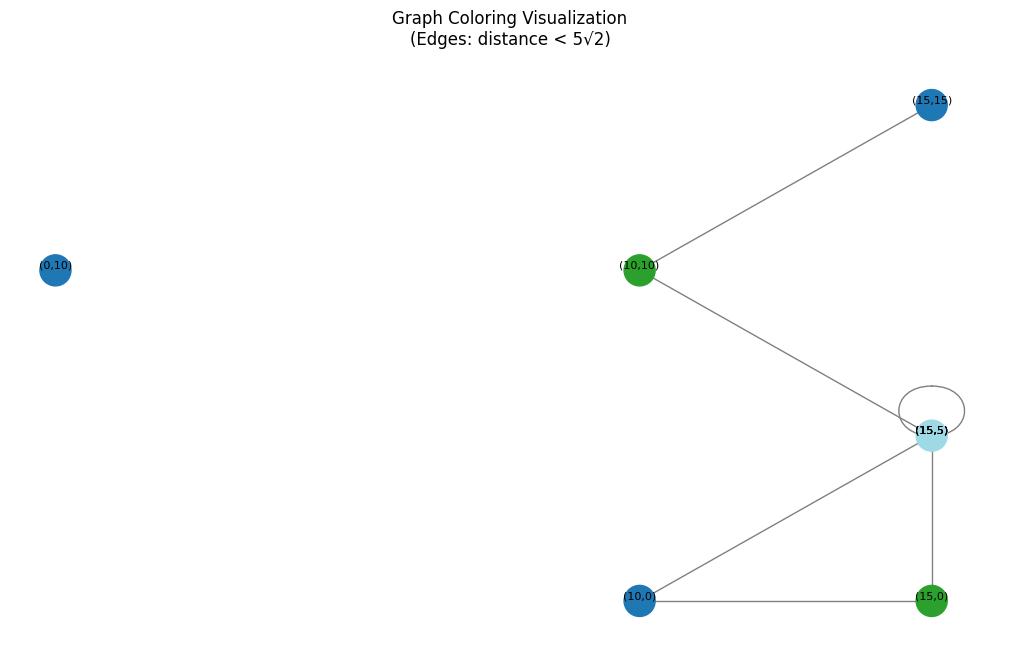

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(0, 0), (10, 10), (5, 10), (5, 0), (0, 5), (5, 0), (5, 5), (10, 5), (10, 5)]
[1, 1, 0, 0, 0, 0, 0, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(5, 10), (5, 0), (0, 5), (5, 0), (5, 5), (10, 5), (10, 5)]
[1, 0, 0, 1, 0, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(5, 0), (0, 5), (5, 5), (10, 5), (10, 5)]
[0, 1, 0, 1, 0]
8.408964152537145
[(5, 0), (5, 5), (10, 5)]
[0, 0, 1]
8.408964152537145
[(5, 0), (5, 5)]
[1, 0]
8.408964152537145
[(5, 5)]
[1]
[[(0, 0), (10, 10)], [(5, 10), (5, 0)], [(0, 5), (10, 5)], [(10, 5)], [(5, 0)], [(5, 5)]]


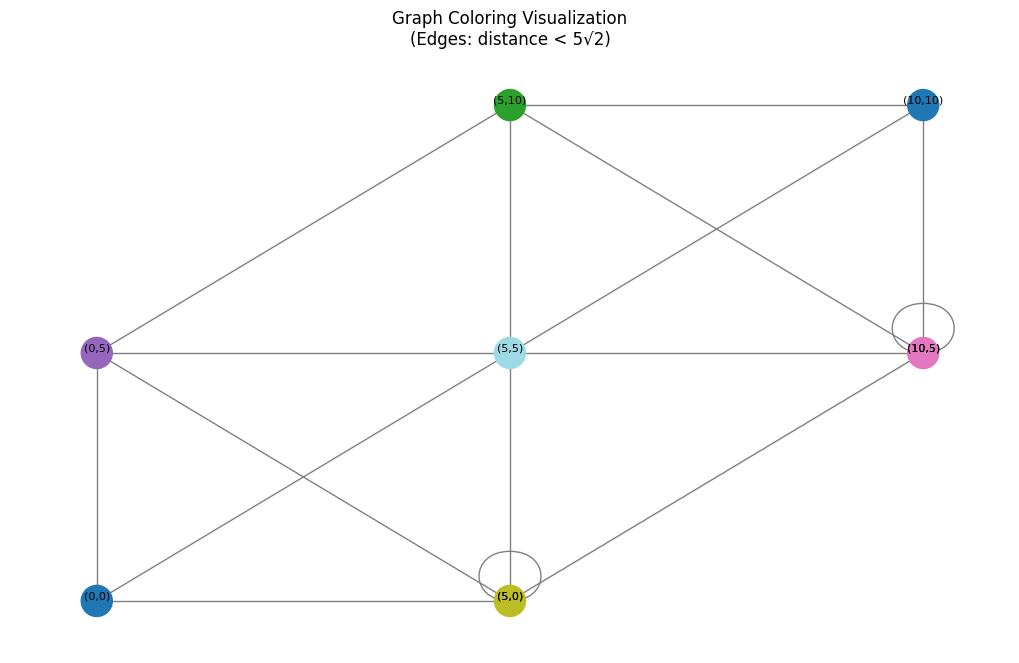

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 15), (15, 5), (5, 0), (10, 10), (15, 15), (0, 0), (0, 10), (10, 10), (0, 10)]
[0, 1, 0, 0, 1, 1, 1, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 15), (5, 0), (10, 10), (10, 10), (0, 10)]
[1, 1, 0, 0, 1]
8.408964152537145
[(10, 10), (10, 10)]
[0, 1]
8.408964152537145
[(10, 10)]
[1]
[[(15, 5), (15, 15), (0, 0), (0, 10)], [(10, 15), (5, 0), (0, 10)], [(10, 10)], [(10, 10)]]


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


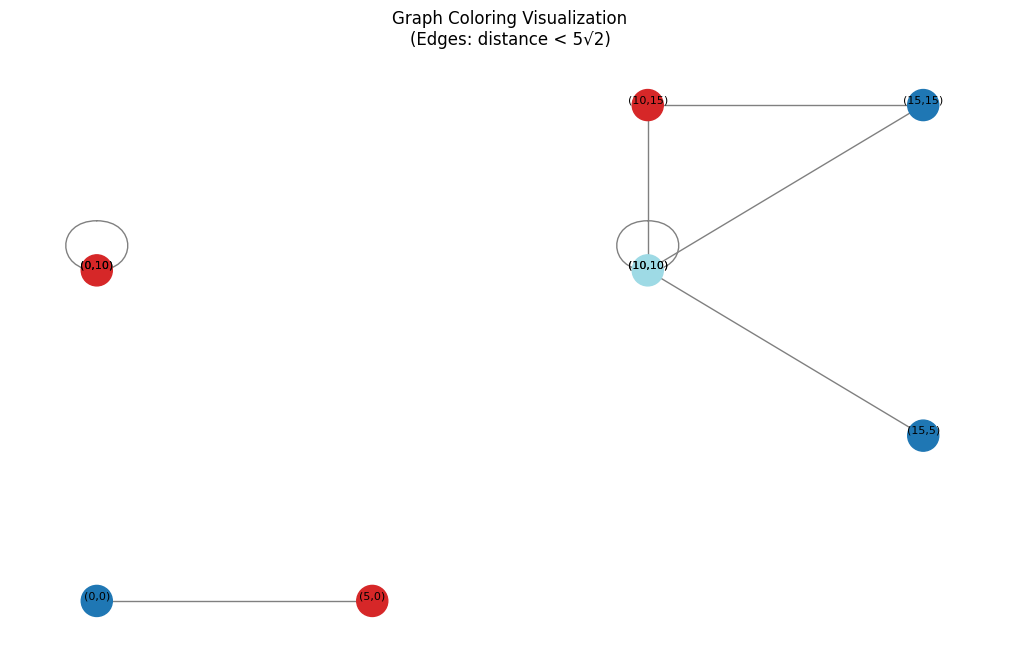

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(15, 10), (15, 15), (15, 5), (10, 10), (15, 10), (10, 0), (0, 5), (0, 0), (10, 5)]
[0, 1, 0, 0, 0, 1, 1, 0, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(15, 10), (15, 5), (10, 10), (15, 10), (0, 0), (10, 5)]
[0, 0, 1, 0, 1, 0]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(15, 10), (15, 5), (15, 10), (10, 5)]
[0, 0, 0, 1]
8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(15, 10), (15, 5), (15, 10)]
[0, 1, 0]
8.408964152537145
[(15, 10), (15, 10)]
[0, 1]
8.408964152537145
[(15, 10)]
[1]
[[(15, 15), (10, 0), (0, 5)], [(10, 10), (0, 0)], [(10, 5)], [(15, 5)], [(15, 10)], [(15, 10)]]


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


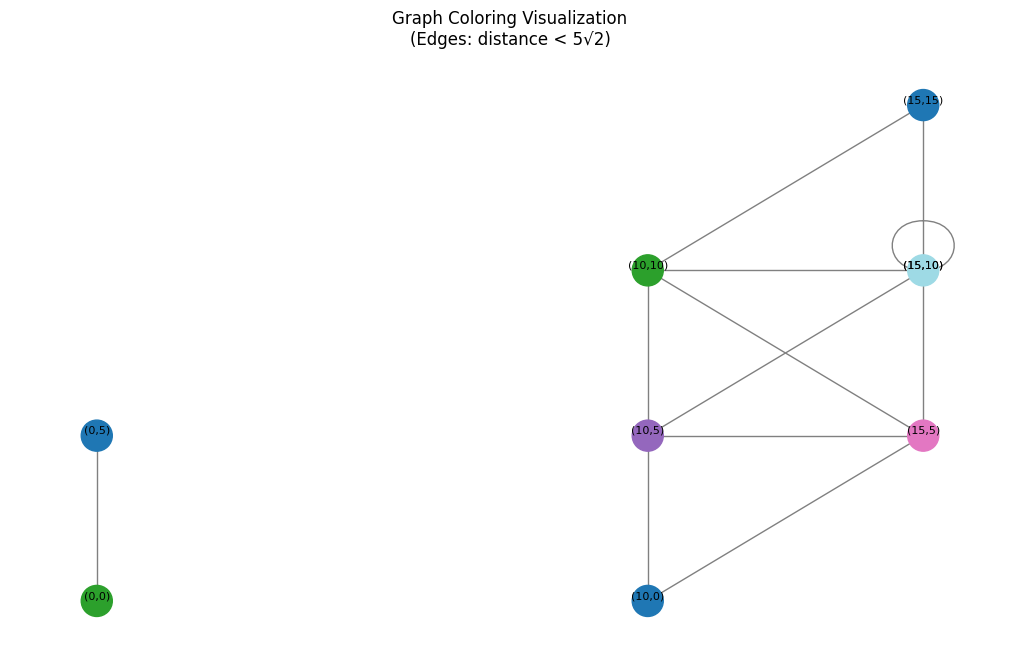

8.408964152537145


/home/rpl20001/anaconda3/envs/yqh/lib/python3.12/site-packages/bloqade/analog/emulate/codegen/hamiltonian.py:83: RuntimeWarning: divide by zero encountered in scalar divide
  rydberg_interaction = RB_C6 / (distance**6)


[(10, 0), (10, 10), (0, 5), (5, 5), (15, 10), (15, 15), (0, 5), (15, 0), (15, 5)]
[0, 0, 1, 0, 0, 1, 0, 1, 0]
8.408964152537145
[(10, 0), (10, 10), (5, 5), (15, 10), (0, 5), (15, 5)]
[1, 0, 0, 1, 1, 0]
8.408964152537145
[(10, 10), (5, 5), (15, 5)]
[0, 1, 1]
8.408964152537145
[(10, 10)]
[1]
[[(0, 5), (15, 15), (15, 0)], [(10, 0), (15, 10), (0, 5)], [(5, 5), (15, 5)], [(10, 10)]]


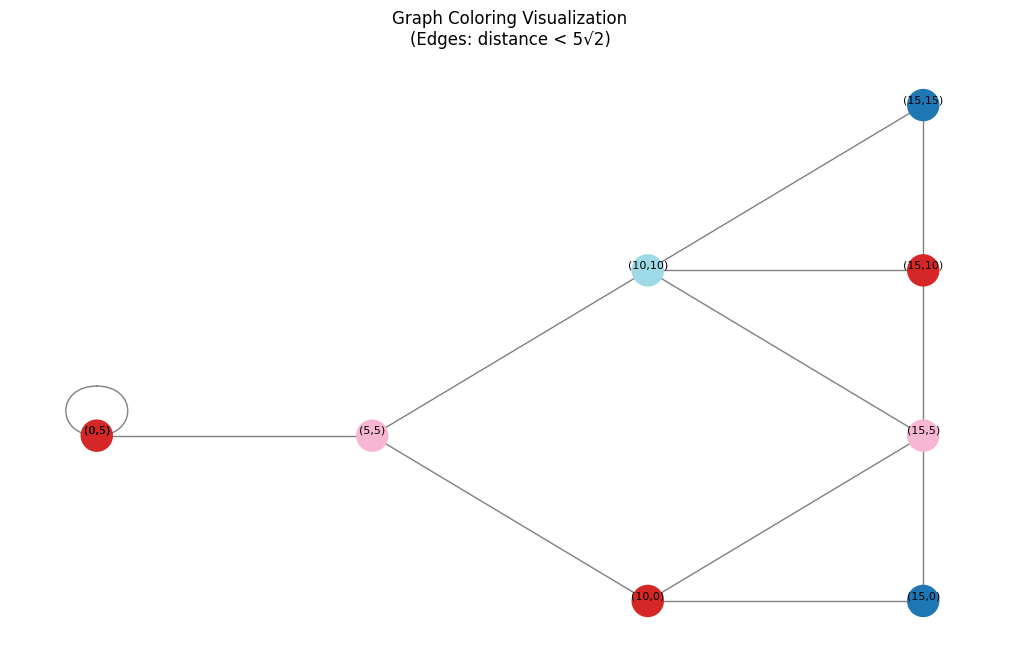

In [44]:

# main
import random

# points = [(0,0), (1,0), (0,1), (0,2), (1,3), (2,0), (2,2), (2,3), (3,0),(3,1), (3,2), (3,3)]
# Initial Points
og_points = [(0,0), (1,0), (0,1), (0,2), (3,2), (3,3)]
og_points = [(0,0), (1,0), (0,1), (0,2), (1,3), (2,0), (2,2), (2,3), (3,0),(3,1), (3,2), (3,3)]
# og_points = [(9.0, 0.0), (9.0, 9.0), (9.0, 22.5), (4.5, 4.5), (9.0, 31.5), (4.5, 18.0), (4.5, 27.0), (4.5, 40.5), (0.0, 13.5), (9.0, 49.5), (0.0, 27.0), (0.0, 36.0), (9.0, 58.5), (0.0, 45.0), (0.0, 54.0), (4.5, 63.0)]
# og_points = [(2.0, 0.0), (2.0, 2.0), (2.0, 5.0), (1.0, 1.0), (2.0, 7.0), (1.0, 4.0), (1.0, 6.0), (1.0, 9.0), (0.0, 3.0), (2.0, 11.0), (0.0, 6.0), (0.0, 8.0), (2.0, 13.0)] #, (0.0, 10.0), (0.0, 12.0), (1.0, 14.0)]
#

unit_tests = []

for i in range(10):
    unit_tests.append([(random.randint(0, 3), random.randint(0, 3)) for _ in range(9)])

for test in unit_tests:
    a = 5
    # a = 1 # a;ready scaled here

    # mul;tiply all the points x5 
    og_points = test
    og_points = [(x*a,y*a) for x,y in og_points] #TODO add back

    points = og_points.copy()
    coloring = []

    while points:
        remaining_set, max_set = run_rydberg(points)
        points = remaining_set
        coloring.append(max_set)

    # plot then colored graph
    # fig, ax = plt.subplots()
    print(coloring)
    visualize_colored_groups(coloring)

In [11]:
example_data = [[(0, 0), (0, 5), (15, 10)], [(5, 0), (0, 10), (15, 15)]]

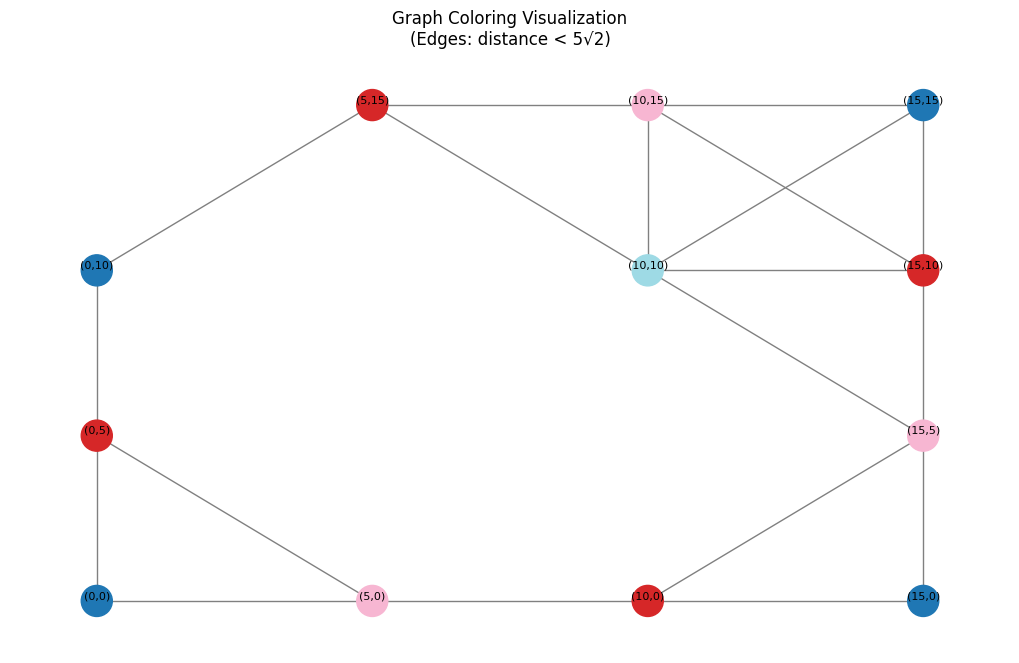

In [32]:
import math
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations

def visualize_colored_groups(data):
    # Create graph and calculate edges
    G = nx.Graph()
    all_points = [point for group in data for point in group]
    
    # Add nodes with position attributes
    for point in all_points:
        G.add_node(point, pos=point)
    
    # Create edges based on distance threshold
    threshold = 5 * math.sqrt(2)
    # threshold = 12
    for (p1, p2) in combinations(all_points, 2):
        distance = math.hypot(p1[0]-p2[0], p1[1]-p2[1])
        if distance <= threshold:
            G.add_edge(p1, p2)
    
    # Create color mapping
    color_map = []
    color_dict = {}
    for color_idx, group in enumerate(data):
        for point in group:
            color_dict[point] = color_idx
    
    # Create ordered color list based on node order
    for node in G.nodes():
        color_map.append(color_dict[node])
    
    # Draw the graph
    pos = nx.get_node_attributes(G, 'pos')
    plt.figure(figsize=(10, 6))
    nx.draw(G, pos, 
            node_color=color_map, 
            cmap=plt.cm.tab20,
            with_labels=False,
            node_size=500,
            edge_color='gray')
    
    # Add coordinate labels
    for point in all_points:
        plt.text(point[0], point[1], f"({point[0]},{point[1]})", 
                 ha='center', va='bottom', fontsize=8)
    
    plt.title("Graph Coloring Visualization\n(Edges: distance < 5√2)")
    plt.grid(True, alpha=0.3)
    plt.show()

# Example usage
visualize_colored_groups(coloring)